Navpreet Kloy, Logan Cheng


Dataset URL: https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset

In [ ]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [ ]:
#load dataset
df = pd.read_csv("UCI_Credit_Card.csv")
df.head()


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [ ]:
# dataset structure overiew including data types and missing values
df.info()
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [ ]:
# statistical overview of the numerical features
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [ ]:
# display all column names in the dataset
print(df.columns.tolist())

['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month']


In [ ]:
# check categorical values
for col in list(df.columns[2:5]) + list(df.columns[6:12]):
    print(df[col].value_counts())
    print()

SEX
2    18112
1    11888
Name: count, dtype: int64

EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64

PAY_0
 0    14737
-1     5686
 1     3688
-2     2759
 2     2667
 3      322
 4       76
 5       26
 8       19
 6       11
 7        9
Name: count, dtype: int64

PAY_2
 0    15730
-1     6050
 2     3927
-2     3782
 3      326
 4       99
 1       28
 5       25
 7       20
 6       12
 8        1
Name: count, dtype: int64

PAY_3
 0    15764
-1     5938
-2     4085
 2     3819
 3      240
 4       76
 7       27
 6       23
 5       21
 1        4
 8        3
Name: count, dtype: int64

PAY_4
 0    16455
-1     5687
-2     4348
 2     3159
 3      180
 4       69
 7       58
 5       35
 6        5
 1        2
 8        2
Name: count, dtype: int64

PAY_5
 0    16947
-1     5539
-2     4546
 2     2626
 3      178
 4       84
 7       58
 5 

In [ ]:
# clean up 'EDUCATION' column values as according to dataset documentation
df['EDUCATION'] = df['EDUCATION'].replace([0,4,5,6], 4)

In [ ]:
#split dataset in features and target variable
x_data=df[['LIMIT_BAL','SEX','EDUCATION','MARRIAGE','AGE','PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6','BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6','PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']]
y_data=df['default.payment.next.month']

In [ ]:
# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.3, random_state=1,stratify = y_data) # 70% training and 30% test

In [ ]:
# use GridSearchCV to find the best Decision Tree parameters
from sklearn.model_selection import GridSearchCV

param_grid = {'max_depth':[3,4,5,6],
              'min_samples_leaf':[20,50,60,80,100],
              'min_samples_split':[2,5,8,10]}

grid = GridSearchCV(DecisionTreeClassifier(class_weight="balanced", random_state=42),
                    param_grid, cv=5)

grid.fit(X_train, y_train)
print(grid.best_params_)


{'max_depth': 5, 'min_samples_leaf': 100, 'min_samples_split': 2}


In [ ]:
# Create Decision Tree classifer object
dt_model = DecisionTreeClassifier(max_depth=5,
    min_samples_leaf=100,
    class_weight="balanced",
    random_state=42,
)

# Train Decision Tree Classifer
dt_model2 = dt_model.fit(X_train,y_train)

#Predict the response for test dataset
y_pred = dt_model2.predict(X_test)

In [ ]:
# Model Accuracy
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.784


In [ ]:
# Measure precision, recall, and f1 score.
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

precision = metrics.precision_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)
f1 = metrics.f1_score(y_test, y_pred)

print(f"The precision of the model is {precision:.2f}.")
print(f"The recall of the model is {recall:.2f}.")
print(f"The F1-score of the model is {f1:.2f}.")

              precision    recall  f1-score   support

           0       0.87      0.85      0.86      7009
           1       0.51      0.55      0.53      1991

    accuracy                           0.78      9000
   macro avg       0.69      0.70      0.69      9000
weighted avg       0.79      0.78      0.79      9000

The precision of the model is 0.51.
The recall of the model is 0.55.
The F1-score of the model is 0.53.


In [ ]:
# use the trained decision tree model to predict whether a customer will default on their payment next month
def predict_default():
    while True:
        try:
            limit_bal = float(input("Enter the credit card limit: "))
            gender = int(input("Enter 1 for male or 2 for female: "))
            education = int(input("Enter education number: 1=graduate school, 2=university, 3=high school, 4=others: "))
            marriage = int(input("Enter martial status: (1 = married; 2 = single; 3 = divorce; 0=others):"))
            age = int(input("Enter age: "))

            # For repayment values,pay_0 values: -2: No consumption; -1: Paid in full; 0: The use of revolving credit; 1 = payment delay for one month; 2 = payment delay for two months; . . .; 8 = payment delay for eight months; 9 = payment delay for nine months and above.
            print('--------')
            print('For repayment status entry: -2: No consumption; -1: Paid in full; 0: revolving credit; 1-8 = number of months payment delay; 9 = payment delay for nine months and above:"')
            pay_0 = int(input("Enter repayment status for last month: "))
            pay_2 = int(input("Enter repayment status 2 months ago: "))
            pay_3 = int(input("Enter repayment status 3 months ago: "))
            pay_4 = int(input("Enter repayment status 4 months ago: "))
            pay_5 = int(input("Enter repayment status 5 months ago: "))
            pay_6 = int(input("Enter repayment status 6 months ago: "))

            # input for bill statement amount for each month
            bill_amt1 = float(input("Enter bill amount for last month: "))
            bill_amt2 = float(input("Enter bill amount 2 months ago: "))
            bill_amt3 = float(input("Enter bill amount 3 months ago: "))
            bill_amt4 = float(input("Enter bill amount 4 months ago: "))
            bill_amt5 = float(input("Enter bill amount 5 months ago: "))
            bill_amt6 = float(input("Enter bill amount 6 months ago: "))

            # input for previous payments paid
            pay_amt1 = float(input("Enter payment amount for last month: "))
            pay_amt2 = float(input("Enter payment amount 2 months ago: "))
            pay_amt3 = float(input("Enter payment amount 3 months ago: "))
            pay_amt4 = float(input("Enter payment amount 4 months ago: "))
            pay_amt5 = float(input("Enter payment amount 5 months ago: "))
            pay_amt6 = float(input("Enter payment amount 6 months ago: "))


            # input validation for non-negative values
            if any(val < 0 for val in [age, limit_bal]):
              print("Error: Please enter non-negative value.")
              continue  #restart the loop

            # input validation for repayment status
            if any(val < -2 or val > 9 for val in [pay_0, pay_2, pay_3,pay_4, pay_5,pay_6]):
                print("Error: Please enter repayment status between -2 and 9.")
                continue  #restart the loop

            # input validation for gender
            if gender not in [1, 2]:
               print("Error: Please enter 1 for male or 2 for female.")
               continue

            # input validation for education
            if education not in [1, 2,3,4]:
               print("Error: Please enter education value between 1-4.")
               continue

            # input validation for marriage
            if marriage not in [0,1,2,3]:
               print("Error: Please enter marriage value between 0-3.")
               continue

            new_customer_data = pd.DataFrame([[limit_bal, gender, education, marriage, age, pay_0, pay_2, pay_3,pay_4, pay_5,pay_6, bill_amt1, bill_amt2, bill_amt3, bill_amt4, bill_amt5, bill_amt6, pay_amt1, pay_amt2, pay_amt3, pay_amt4, pay_amt5, pay_amt6]],
                                           columns=['LIMIT_BAL','SEX','EDUCATION','MARRIAGE','AGE','PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6','BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6','PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6'])

            prediction = dt_model2.predict(new_customer_data)[0]

            if prediction == 1:
                print("Prediction: Customer is likely to default next payment.")
            else:
                print("Prediction: Customer is not likely to default next payment.")

            another_customer = input("Enter data for another customer? (yes/no): ")
            if another_customer.lower() != 'yes':
                break #exit loop
        except ValueError:
            print("Invalid input. Please enter valid numerical values.")
        except Exception as e:
            print(e)

predict_default()

Enter the credit card limit: 10000
Enter 1 for male or 2 for female: 2
Enter education number: 1=graduate school, 2=university, 3=high school, 4=others: 1
Enter martial status: (1 = married; 2 = single; 3 = divorce; 0=others):1
Enter age: 33
--------
For repayment status entry: -2: No consumption; -1: Paid in full; 0: revolving credit; 1-8 = number of months payment delay; 9 = payment delay for nine months and above:"
Enter repayment status for last month: -2
Enter repayment status 2 months ago: -2
Enter repayment status 3 months ago: -1
Enter repayment status 4 months ago: 0
Enter repayment status 5 months ago: 4
Enter repayment status 6 months ago: 2
Enter bill amount for last month: 400
Enter bill amount 2 months ago: 500
Enter bill amount 3 months ago: 2000
Enter bill amount 4 months ago: 5000
Enter bill amount 5 months ago: 10
Enter bill amount 6 months ago: 0
Enter payment amount for last month: 400
Enter payment amount 2 months ago: 300
Enter payment amount 3 months ago: 200
Ent

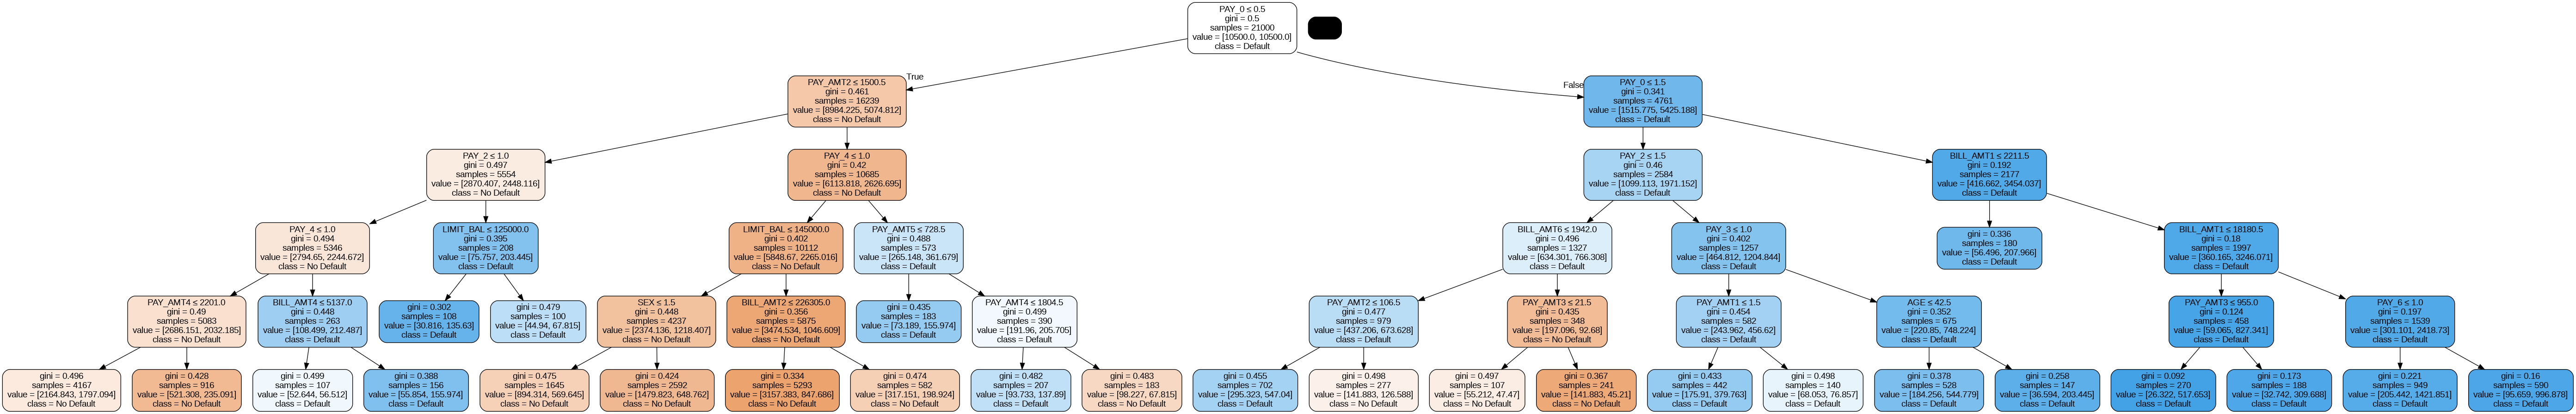

In [ ]:
# visualize the Decision Tree model
from sklearn.tree import export_graphviz
from six import StringIO
from IPython.display import Image
import pydotplus


dot_data = StringIO()
export_graphviz(dt_model2, out_file=dot_data,feature_names= x_data.columns,
                filled=True, rounded=True,
                special_characters=True,class_names=['No Default','Default'])
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png('default.png')
Image(graph.create_png())

The dataset used is about credit card clients and whether the client will have default payment. It includes basic demographic information and information about credit, status, and payment history.  A decision tree algorithm was used to build a model to predict whether the client will have default payment next month. A decision tree repeatedly splits the dataset into two groups based on feature predictor variables provided, until it can’t be branched or split any further as specified. The dataset contains a total of 25 variables, out of which 23 were chosen as the predictor variables for the prediction. The dataset was split into training and test sets. Then GridSearchCV was used to test and find the possible parameters for the decision model. The model was then trained and for each client in the test set, a prediction was made. The model had a 78.4% accuracy, meaning the predictions were correct 78.4% of the time when compared to the actual corresponding outcome in the dataset. The model was further analyzed using precision, recall and F1-score metrics to determine the strength of the model. The F-1 score, which represents the balance between precision and recall, for no default in payment was 86% and for default it was 53%. This means the model is stronger at predicting a customer being no default in payment next month compared to those who will default payment next month.


Node explantion: PAY_AMT2 <= 1500.5, gini: 0.461, samples: 16,239, value: [8,984, 5,074], class: No Default.

From the tree branch, the node with feature PAY_AMT2 <= 1500.5 represents the decision rule for the split on this node. The next step will check the payment amount for 2 months ago. If the payment amount is less than or equal to 1500.50, the samples go to the true branch. If the pay amount is greater, samples follow the false branch. The gini is 0.461, this is the heterogeneous level for this node. It is mostly mixed in this case, containing both classes. The sample value of 16,239 means there are 16,239 samples in this node. The value gives a breakdown of how many classes are in the node. This node has about 8,984 no default samples and about 5,074 default samples. The class for the node is determined by the highest value in the value field. In this node, the class with the highest value is no default class. Overall, it means if the pay amount for 2 months ago is less than or equal to 1500.50, the model predicts it is most likely a no default case.
